The data contains banknotes, with 0 the bank note being authentic, and 1 the bank note being fake. The 4 variables used to predict this are: the variance of Wavelet Transformed image.
 skewness of Wavelet Transformed image, curtosis of Wavelet Transformed image , entropy of image . These are all continuos values. For the analysis, I standardized the data. With regards to KNN, the distance metric I used was Euclidean distance.

Predictions: [0 0 1 0 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 1 1 1 1 1 1 0 1 0 1 0 1 1
 1 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 1 1 0 1 0 1 0 1 0 1 0
 1 1 1 1 0 0 0 0 1 1 0 1 1 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1
 0 0 1 0 0 1 0 1 0 0 0 1 1 1 0 1 0 1 1 0 0 1 0 1 1 0 1 0 0 1 1 1 0 1 1 1 1
 0 1 1 1 0 0 0 0 0 1 0 0 1 0 1 1 0 1 1 1 0 0 1 0 0 1 0 1 1 0 0 1 1 1 0 0 1
 0 0 0 1 0 0 1 0 1 0 1 1 0 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 1 0 0 1 0
 1 1 0 0 1 1 0 1 0 0 1 0 1 0 1 0 0 1 1 1 1 0 0 1 0 1 1 1 0 0 0 1 0 1 0 0 1
 1 0 0 0 0 0 1 0 1 1 1 1 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 0 1
 0 0 1 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 0 0
 0 1 1 1 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0
 1 0 1 0 0 1 0 1 1 0 1 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1
 0 0 0 0 1]
True labels: [0 0 1 0 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 1 1 1 1 1 1 0 1 0 1 0 1 1
 1 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 1 1 0 1 0

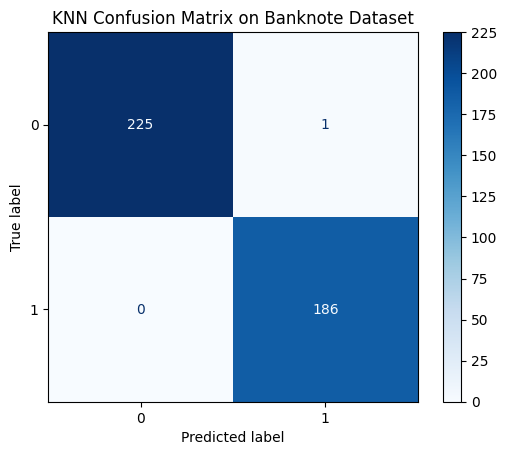

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ml import standardize_vectors, train_test_split_arrays, KNN
# Only used for displays
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- 1. Load Banknote Authentication dataset ---
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
df = pd.read_csv(url, header=None)

# Features (X) and target (y)
X = df.iloc[:, :-1].values   # 4 numeric features
y = df.iloc[:, -1].values    # 0 = authentic, 1 = fake

# --- 2. Standardize features ---
X = standardize_vectors(X)

# --- 3. Train-test split ---
X_train, y_train, X_test, y_test = train_test_split_arrays(
    X, y, train_ratio=0.7, seed=42
)

# --- 4. Initialize KNN with training data ---
knn = KNN(X_train, y_train)

# --- 5. Predict on test set (loop because predict handles one sample at a time) ---
y_pred = np.array([knn.predict(x, classify=True, K=5) for x in X_test])


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("KNN Confusion Matrix on Banknote Dataset")
plt.show()


We can see from the chart that knn is excellent at predicting whether a check is authentic or not.